Full Data Period: 2020-01-17 → 2026-03-20
Total days: 1527

Train period: 2020-01-17 → 2022-12-30
Test period : 2023-01-02 → 2026-03-20
Train size: 734, Test size: 793

Running TRAIN grid search...

=== TOP 5 TRAIN RESULTS ===
   threshold  window  train_cagr  train_sharpe  train_max_dd   score
0       0.30       4      0.1410        0.7345       -0.2527  0.3554
1       0.30       5      0.1477        0.7598       -0.2704  0.3543
2       0.15       4      0.1406        0.7244       -0.2615  0.3321
3       0.20       4      0.1373        0.7134       -0.2615  0.3211
4       0.15       5      0.1496        0.7555       -0.3033  0.3006

Running TEST validation...

=== TEST RESULTS (OUT-OF-SAMPLE) ===
   threshold  window  train_sharpe  test_sharpe  test_max_dd
0       0.30     4.0        0.7345       0.0098      -0.1723
1       0.30     5.0        0.7598       0.0607      -0.1901
2       0.15     4.0        0.7244      -0.2338      -0.2201
3       0.20     4.0        0.7134      -0.2105  

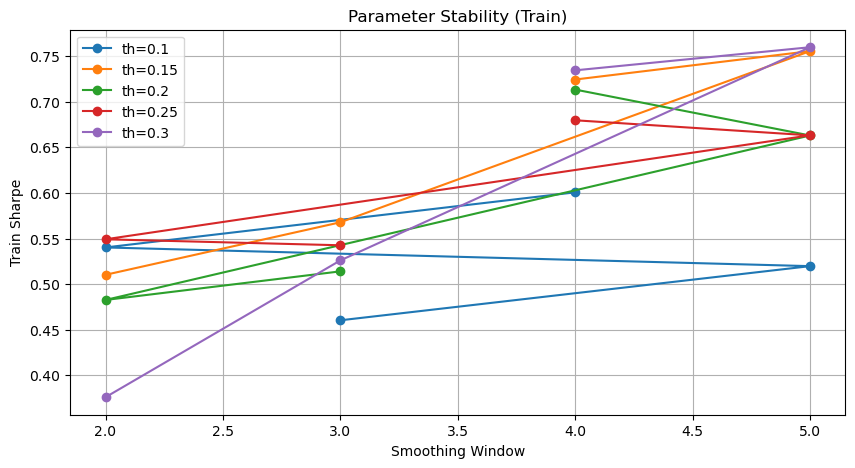

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. LOAD DATA
# =============================================
market = pd.read_csv("../backtesting/market_backtest_v7.csv")
market["Date"] = pd.to_datetime(market["Date"])
market = market.set_index("Date").sort_index()

print(f"Full Data Period: {market.index[0].date()} → {market.index[-1].date()}")
print(f"Total days: {len(market)}\n")

# =============================================
# 2. TRAIN / TEST SPLIT (FIXED)
# =============================================
split_date = "2023-01-01"

train = market[market.index < split_date]
test  = market[market.index >= split_date]

print(f"Train period: {train.index[0].date()} → {train.index[-1].date()}")
print(f"Test period : {test.index[0].date()} → {test.index[-1].date()}")
print(f"Train size: {len(train)}, Test size: {len(test)}\n")

# Safety check
if len(train) == 0 or len(test) == 0:
    raise ValueError("Train/Test split failed ❌")

# =============================================
# 3. STRATEGY FUNCTION
# =============================================
def run_strategy(df, mom_threshold=0.20, smooth_window=3, cost_bps=5):
    
    data = df.copy()
    
    # Momentum signal
    signal = np.where(
        data["mom_20_norm"] > mom_threshold, 1,
        np.where(data["mom_20_norm"] < -mom_threshold, -1, 0)
    )
    
    # Smoothing
    signal_smooth = pd.Series(signal, index=data.index).rolling(
        window=smooth_window, min_periods=1
    ).mean()
    
    # Position
    position = np.where(signal_smooth > 0.5, 1,
                       np.where(signal_smooth < -0.5, -1, 0))
    
    data["position"] = pd.Series(position, index=data.index)
    
    # Transaction cost
    position_change = data["position"].diff().abs().fillna(0)
    cost = position_change * (cost_bps / 10000)
    
    # Strategy return
    data["strategy_ret"] = data["position"].shift(1) * data["nifty_ret"] - cost
    
    return data.dropna(subset=["strategy_ret"])

# =============================================
# 4. EVALUATION FUNCTION
# =============================================
def evaluate(df):
    ret = df["strategy_ret"]
    equity = (1 + ret).cumprod()
    
    if len(ret) == 0:
        return 0, 0, 0, 0
    
    cagr = equity.iloc[-1] ** (252 / len(ret)) - 1
    sharpe = ret.mean() / ret.std() * np.sqrt(252)
    max_dd = (equity / equity.cummax() - 1).min()
    
    # Risk-adjusted score
    score = sharpe - 1.5 * abs(max_dd)
    
    return cagr, sharpe, max_dd, score

# =============================================
# 5. GRID SEARCH (TRAIN ONLY)
# =============================================
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]
smooth_windows = [2, 3, 4, 5]

results = []

print("Running TRAIN grid search...\n")

for th in thresholds:
    for w in smooth_windows:
        
        strat = run_strategy(train, th, w, cost_bps=5)
        cagr, sharpe, max_dd, score = evaluate(strat)
        
        results.append({
            "threshold": th,
            "window": w,
            "train_cagr": cagr,
            "train_sharpe": sharpe,
            "train_max_dd": max_dd,
            "score": score
        })

results_df = pd.DataFrame(results).sort_values("score", ascending=False).reset_index(drop=True)

print("=== TOP 5 TRAIN RESULTS ===")
print(results_df.head(5).round(4))

# =============================================
# 6. TEST VALIDATION (CRITICAL)
# =============================================
top5 = results_df.head(5)

test_results = []

print("\nRunning TEST validation...\n")

for _, row in top5.iterrows():
    
    strat_test = run_strategy(
        test,
        mom_threshold=row["threshold"],
        smooth_window=int(row["window"]),
        cost_bps=5
    )
    
    cagr, sharpe, max_dd, _ = evaluate(strat_test)
    
    test_results.append({
        "threshold": row["threshold"],
        "window": row["window"],
        "train_sharpe": row["train_sharpe"],
        "test_sharpe": sharpe,
        "test_max_dd": max_dd
    })

df_test = pd.DataFrame(test_results)

print("=== TEST RESULTS (OUT-OF-SAMPLE) ===")
print(df_test.round(4))

# =============================================
# 7. PARAMETER STABILITY VISUAL
# =============================================
plt.figure(figsize=(10, 5))

for th in thresholds:
    subset = results_df[results_df["threshold"] == th]
    plt.plot(subset["window"], subset["train_sharpe"], marker='o', label=f"th={th}")

plt.xlabel("Smoothing Window")
plt.ylabel("Train Sharpe")
plt.title("Parameter Stability (Train)")
plt.legend()
plt.grid(True)
plt.show()

# =============================================
# 8. SAVE RESULTS
# =============================================
results_df.to_csv("../backtesting/parameter_train_results_final.csv", index=False)
df_test.to_csv("../backtesting/parameter_test_results_final.csv", index=False)